# Notebook 01: Build feature matrix (lobe-targeted aggregation)

This notebook reads the raw per-participant FFT CSVs and builds a participant-level feature matrix grouped by **primary target lobe** as specified in `stimuli.csv`. Each task is categorized by its `primary_lobe_targeted` field, which reflects the experimental design choice of the original study.

**Aggregation**: for each (participant, lobe category, channel, frequency band), the value is the median FFT power across all time-window rows from all tasks belonging to that category. Median chosen for robustness to artifact-driven outliers in the raw windowed data.

**Inputs:**
- `data/eeg_features/BA*/2_emotiv_fft_values.csv` (one per participant)
- `data/outcomes.csv`
- `data/stimuli.csv` (provides primary_lobe_targeted for each task)

**Outputs (saved to `outputs/`):**
- `feature_matrix_raw.csv`, `feature_matrix.csv`, `metadata.csv`, `build_report.txt`

## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

PROJECT_ROOT = Path(".").resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
EEG_DIR = DATA_DIR / "eeg_features"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

report_lines = []
def log(msg):
    print(msg)
    report_lines.append(msg)

log(f"Project root: {PROJECT_ROOT}")
log(f"EEG data dir: {EEG_DIR}")
log(f"Output dir:   {OUTPUT_DIR}")

Project root: C:\Users\lukab\Desktop\Algebra EEG\Project NMF
EEG data dir: C:\Users\lukab\Desktop\Algebra EEG\Project NMF\data\eeg_features
Output dir:   C:\Users\lukab\Desktop\Algebra EEG\Project NMF\outputs


## Load task-to-lobe mapping from stimuli.csv

Rather than hardcoding categories, we read `stimuli.csv` and use its `primary_lobe_targeted` field. This sources the categorization directly from the experimenters' own classification.

In [2]:
stimuli_df = pd.read_csv(DATA_DIR / "stimuli.csv")
log(f"Loaded stimuli.csv: {len(stimuli_df)} tasks")
log(f"Columns: {list(stimuli_df.columns)}")

# Sanitize category names for use as column prefixes (lower case, replace dashes)
def to_cat_key(lobe_str):
    return lobe_str.strip().lower().replace("-", "_").replace(" ", "_")

stimuli_df["category"] = stimuli_df["primary_lobe_targeted"].map(to_cat_key)

TASK_TO_CATEGORY = dict(zip(stimuli_df["original_stimuli_name"], stimuli_df["category"]))

log("\nTasks per category (from primary_lobe_targeted):")
for cat in sorted(stimuli_df["category"].unique()):
    tasks_in_cat = stimuli_df[stimuli_df["category"] == cat]["original_stimuli_name"].tolist()
    log(f"  {cat} ({len(tasks_in_cat)} tasks): {tasks_in_cat}")

log(f"\nTotal tasks mapped: {len(TASK_TO_CATEGORY)}")

Loaded stimuli.csv: 37 tasks
Columns: ['original_stimuli_name', 'description', 'primary_lobe_targeted', 'secondary_lobe_targeted', 'tertiary_lobe_targeted', 'cognitive_domain', 'expected_eeg_signature', 'dominant_network', 'expected_network_channels']

Tasks per category (from primary_lobe_targeted):
  frontal (6 tasks): ['baseline_talk', 'prefrontal1', 'prefrontal2', 'prefrontal3_reading', 'saying_words_based_on_cat', 'saying_words_based_on_cat2']
  frontal_central (6 tasks): ['gyrus_left_open', 'gyrus_right_open', 'gyrus_left_closed_eyes', 'gyrus_right_closed_eyes', 'gyrus_coord', 'gyrus_coord2']
  occipital (1 tasks): ['occipital4']
  parietal (9 tasks): ['frontal2_memorization', 'frontal2_recall', 'valdo1', 'valdo2', 'valdo3', 'imagine_way_home', 'parietal_2d_3d', 'parietal_next_in_seq', 'parietal_next_in_seq2']
  temporal (15 tasks): ['instructions_listening', 'frontal1_memorization', 'frontal1_recall', 'frontal3_saying_outloud', 'frontal3_recall', 'temporal_how_many_instruments1'

## Load metadata

In [3]:
outcomes = pd.read_csv(DATA_DIR / "outcomes.csv")
log(f"Outcomes file: {len(outcomes)} participants with metadata")
log(f"Columns: {list(outcomes.columns)}")
outcomes = outcomes.rename(columns={"ID": "participant_id"})

Outcomes file: 100 participants with metadata
Columns: ['ID', 'Age', 'Gender', 'Residential Area (Urban/Rural)', 'From City', 'Single/NotSingle', 'Education', 'Field of Study', 'Occupation', '# of LanguagesSpeak', 'UsedToDoSport', 'NowDoingSports_aWeek', 'PlayingAnInstrument', 'History of Neurological Disorders', 'Medication Usage', 'Average Sleep Hours per Night', 'Smoking (0,1,2,3)', 'Alchocol (0,1,2,3)']


## Find participant folders

In [4]:
def ba_sort_key(p):
    m = re.match(r"BA(\d+)", p.name)
    return int(m.group(1)) if m else 99999

participant_folders = sorted(
    [p for p in EEG_DIR.iterdir() if p.is_dir() and re.match(r"BA\d+", p.name)],
    key=ba_sort_key,
)
log(f"Found {len(participant_folders)} participant folders")
log(f"First 5: {[p.name for p in participant_folders[:5]]}")
log(f"Last 5:  {[p.name for p in participant_folders[-5:]]}")

folder_ids = set(p.name for p in participant_folders)
outcome_ids = set(outcomes["participant_id"])
in_folders_not_outcomes = folder_ids - outcome_ids
in_outcomes_not_folders = outcome_ids - folder_ids
if in_folders_not_outcomes:
    log(f"WARNING: {len(in_folders_not_outcomes)} folders without outcomes: {sorted(in_folders_not_outcomes)}")
if in_outcomes_not_folders:
    log(f"NOTE: {len(in_outcomes_not_folders)} outcomes without folders: {sorted(in_outcomes_not_folders)}")

Found 86 participant folders
First 5: ['BA1', 'BA2', 'BA3', 'BA4', 'BA5']
Last 5:  ['BA89', 'BA90', 'BA91', 'BA92', 'BA93']
NOTE: 14 outcomes without folders: ['BA10', 'BA100', 'BA101', 'BA40', 'BA41', 'BA54', 'BA55', 'BA67', 'BA88', 'BA94', 'BA96', 'BA97', 'BA98', 'BA99']


## Inspect one participant

In [5]:
FREQ_BANDS = ["Theta", "Alpha", "BetaL", "BetaH", "Gamma"]
CHANNELS = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1",
            "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]
POW_COLS = [f"POW.{ch}.{band}" for ch in CHANNELS for band in FREQ_BANDS]
log(f"Expecting {len(POW_COLS)} power features ({len(CHANNELS)} channels x {len(FREQ_BANDS)} bands)")

ex_path = participant_folders[0] / "2_emotiv_fft_values.csv"
ex_df = pd.read_csv(ex_path)
log(f"\nExample participant: {participant_folders[0].name}")
log(f"  Raw shape: {ex_df.shape}")
log(f"  Unique task names: {ex_df['task_name'].nunique()}")

ex_df = ex_df.copy()
ex_df["category"] = ex_df["task_name"].map(TASK_TO_CATEGORY)
log(f"  Rows categorized: {ex_df['category'].notna().sum()}")
log(f"  Rows in tasks not in stimuli.csv: {ex_df['category'].isna().sum()}")
log(f"\n  Rows per category:")
for cat, count in ex_df['category'].value_counts().sort_index().items():
    log(f"    {cat}: {count}")

Expecting 70 power features (14 channels x 5 bands)

Example participant: BA1
  Raw shape: (9850, 86)
  Unique task names: 92
  Rows categorized: 3841
  Rows in tasks not in stimuli.csv: 6009

  Rows per category:
    frontal: 724
    frontal_central: 523
    occipital: 153
    parietal: 1266
    temporal: 1175


## Aggregate features per participant

For each participant: filter to rows whose `task_name` is mapped to a category, compute median power per (category, channel, band), flatten into a single row with feature names `{category}__POW.{channel}.{band}`.

In [6]:
def load_and_aggregate(folder):
    pid = folder.name
    fpath = folder / "2_emotiv_fft_values.csv"
    if not fpath.exists():
        return pid, None, "File not found"
    try:
        df = pd.read_csv(fpath)
    except Exception as e:
        return pid, None, f"Read error: {e}"

    missing = [c for c in POW_COLS + ["task_name"] if c not in df.columns]
    if missing:
        return pid, None, f"Missing columns: {missing[:5]}..."

    df = df.copy()
    df["category"] = df["task_name"].map(TASK_TO_CATEGORY)
    df = df[df["category"].notna()]
    if len(df) == 0:
        return pid, None, "No categorized rows"

    # Median across all time-window rows within each (category, channel, band)
    agg = df.groupby("category")[POW_COLS].median()
    flat = agg.stack()
    flat.index = [f"{cat}__{feat}" for cat, feat in flat.index]
    flat.name = pid
    return pid, flat, f"OK ({agg.shape[0]} categories)"

results, messages = {}, {}
for folder in participant_folders:
    pid, flat, msg = load_and_aggregate(folder)
    messages[pid] = msg
    if flat is not None:
        results[pid] = flat

log(f"\nProcessed {len(participant_folders)} folders, {len(results)} produced data")
problems = {pid: msg for pid, msg in messages.items() if not msg.startswith("OK")}
if problems:
    log(f"\nProblems encountered ({len(problems)}):")
    for pid, msg in problems.items():
        log(f"  {pid}: {msg}")


Processed 86 folders, 86 produced data


## Assemble matrix

In [7]:
feature_matrix_raw = pd.DataFrame(results).T
feature_matrix_raw.index.name = "participant_id"
log(f"\nFeature matrix shape (before NaN handling): {feature_matrix_raw.shape}")
n_cats = stimuli_df['category'].nunique()
log(f"Expected if all categories present per participant: {n_cats} categories x {len(POW_COLS)} = {n_cats * len(POW_COLS)} columns")


Feature matrix shape (before NaN handling): (86, 350)
Expected if all categories present per participant: 5 categories x 70 = 350 columns


In [8]:
missing_per_participant = feature_matrix_raw.isna().sum(axis=1)
missing_per_feature = feature_matrix_raw.isna().sum(axis=0)

log(f"\nMissingness summary:")
log(f"  Participants with any missing features: {(missing_per_participant > 0).sum()}")
log(f"  Features missing in any participant:    {(missing_per_feature > 0).sum()}")
log(f"  Overall fraction missing:               {feature_matrix_raw.isna().mean().mean():.4f}")

if (missing_per_participant > 0).any():
    log("\n  Participants with most missing features:")
    for pid, n in missing_per_participant.sort_values(ascending=False).head(10).items():
        if n > 0:
            log(f"    {pid}: {n} missing ({100*n/feature_matrix_raw.shape[1]:.1f}%)")


Missingness summary:
  Participants with any missing features: 0
  Features missing in any participant:    0
  Overall fraction missing:               0.0000


## Handle missingness

In [9]:
MISSING_THRESHOLD = 0.10
missing_frac = feature_matrix_raw.isna().mean(axis=1)
to_drop = missing_frac[missing_frac > MISSING_THRESHOLD].index.tolist()
if to_drop:
    log(f"\nDropping {len(to_drop)} participants with >{int(100*MISSING_THRESHOLD)}% missing features:")
    for pid in to_drop:
        log(f"  {pid} ({100*missing_frac[pid]:.1f}% missing)")
else:
    log(f"\nNo participants exceed the {int(100*MISSING_THRESHOLD)}% threshold")

feature_matrix_raw = feature_matrix_raw.drop(index=to_drop)
log(f"Matrix shape after exclusions: {feature_matrix_raw.shape}")

n_imputed = feature_matrix_raw.isna().sum().sum()
if n_imputed > 0:
    feature_matrix_raw = feature_matrix_raw.fillna(feature_matrix_raw.median())
    log(f"Imputed {n_imputed} missing cells with per-feature median")
else:
    log("No remaining missing values to impute")


No participants exceed the 10% threshold
Matrix shape after exclusions: (86, 350)
No remaining missing values to impute


## Normalize (log + 95-CI winsorization + min-max to [0, 1])

In [10]:
# Step 1: log(1+x) transform — compress the heavy right tail
feature_matrix_log = np.log1p(feature_matrix_raw)

# Step 2: per-feature winsorization at 1st and 99th percentiles
# Caps extreme values to reduce the influence of artifact-driven outliers on subsequent scaling
LOWER_PCT = 2.5
UPPER_PCT = 97.5
lower_caps = feature_matrix_log.quantile(LOWER_PCT / 100, axis=0)
upper_caps = feature_matrix_log.quantile(UPPER_PCT / 100, axis=0)
feature_matrix_winsor = feature_matrix_log.clip(lower=lower_caps, upper=upper_caps, axis=1)

n_capped_low  = ((feature_matrix_log < lower_caps).sum().sum())
n_capped_high = ((feature_matrix_log > upper_caps).sum().sum())
total_cells   = feature_matrix_log.size
log(f"\nWinsorization at {LOWER_PCT}th/{UPPER_PCT}th percentile (per feature):")
log(f"  Cells capped at lower bound: {n_capped_low} ({100*n_capped_low/total_cells:.2f}%)")
log(f"  Cells capped at upper bound: {n_capped_high} ({100*n_capped_high/total_cells:.2f}%)")
log(f"  Total cells affected:        {n_capped_low + n_capped_high} ({100*(n_capped_low+n_capped_high)/total_cells:.2f}%)")

# Step 3: per-feature min-max scaling to [0, 1] (now driven by winsorized values, not extremes)
f_min = feature_matrix_winsor.min(axis=0)
f_max = feature_matrix_winsor.max(axis=0)
f_range = (f_max - f_min).replace(0, 1)
feature_matrix = (feature_matrix_winsor - f_min) / f_range

log(f"\nNon-normalized matrix range: [{feature_matrix_raw.values.min():.4f}, {feature_matrix_raw.values.max():.4f}]")
log(f"Mean: {feature_matrix_raw.values.mean():.4f}, Std: {feature_matrix_raw.values.std():.4f}")

log(f"\nNormalized matrix range: [{feature_matrix.values.min():.4f}, {feature_matrix.values.max():.4f}]")
log(f"Mean: {feature_matrix.values.mean():.4f}, Std: {feature_matrix.values.std():.4f}")

constant = ((f_max - f_min) == 0).sum()
if constant > 0:
    log(f"WARNING: {constant} features have zero variance after winsorization")


Winsorization at 2.5th/97.5th percentile (per feature):
  Cells capped at lower bound: 1050 (3.49%)
  Cells capped at upper bound: 1050 (3.49%)
  Total cells affected:        2100 (6.98%)

Non-normalized matrix range: [0.0229, 542.1499]
Mean: 1.3979, Std: 5.0811

Normalized matrix range: [0.0000, 1.0000]
Mean: 0.3790, Std: 0.2536


## Align with metadata

In [11]:
metadata = outcomes[outcomes["participant_id"].isin(feature_matrix.index)].copy()
metadata = metadata.set_index("participant_id").reindex(feature_matrix.index).reset_index()

no_metadata = metadata[metadata["Age"].isna()]["participant_id"].tolist()
if no_metadata:
    log(f"\nDropping {len(no_metadata)} participants with no metadata: {no_metadata}")
    feature_matrix = feature_matrix.drop(index=no_metadata)
    feature_matrix_raw = feature_matrix_raw.drop(index=no_metadata)
    metadata = metadata[~metadata["participant_id"].isin(no_metadata)].reset_index(drop=True)

assert (feature_matrix.index == metadata["participant_id"]).all(), "Row alignment broken!"
log(f"\nFinal aligned dataset: {len(feature_matrix)} participants")


Final aligned dataset: 86 participants


## Sanity checks

In [12]:
log("\n=== Cohort characteristics ===")
log(f"N = {len(metadata)}")
log(f"\nRelationship status:")
log(metadata["Single/NotSingle"].value_counts().to_string())
log(f"\nAge: mean={metadata['Age'].mean():.1f}, SD={metadata['Age'].std():.1f}, range={metadata['Age'].min()}-{metadata['Age'].max()}")
log(f"Gender: {dict(metadata['Gender'].value_counts())}")

log("\n=== Feature columns by category ===")
category_counts = {}
for col in feature_matrix.columns:
    cat = col.split("__")[0]
    category_counts[cat] = category_counts.get(cat, 0) + 1
for cat in sorted(category_counts.keys()):
    log(f"  {cat}: {category_counts[cat]} features")


=== Cohort characteristics ===
N = 86

Relationship status:
Single/NotSingle
NotSingle    66
Single       20

Age: mean=36.4, SD=11.0, range=20-62
Gender: {'M': 44, 'F': 42}

=== Feature columns by category ===
  frontal: 70 features
  frontal_central: 70 features
  occipital: 70 features
  parietal: 70 features
  temporal: 70 features


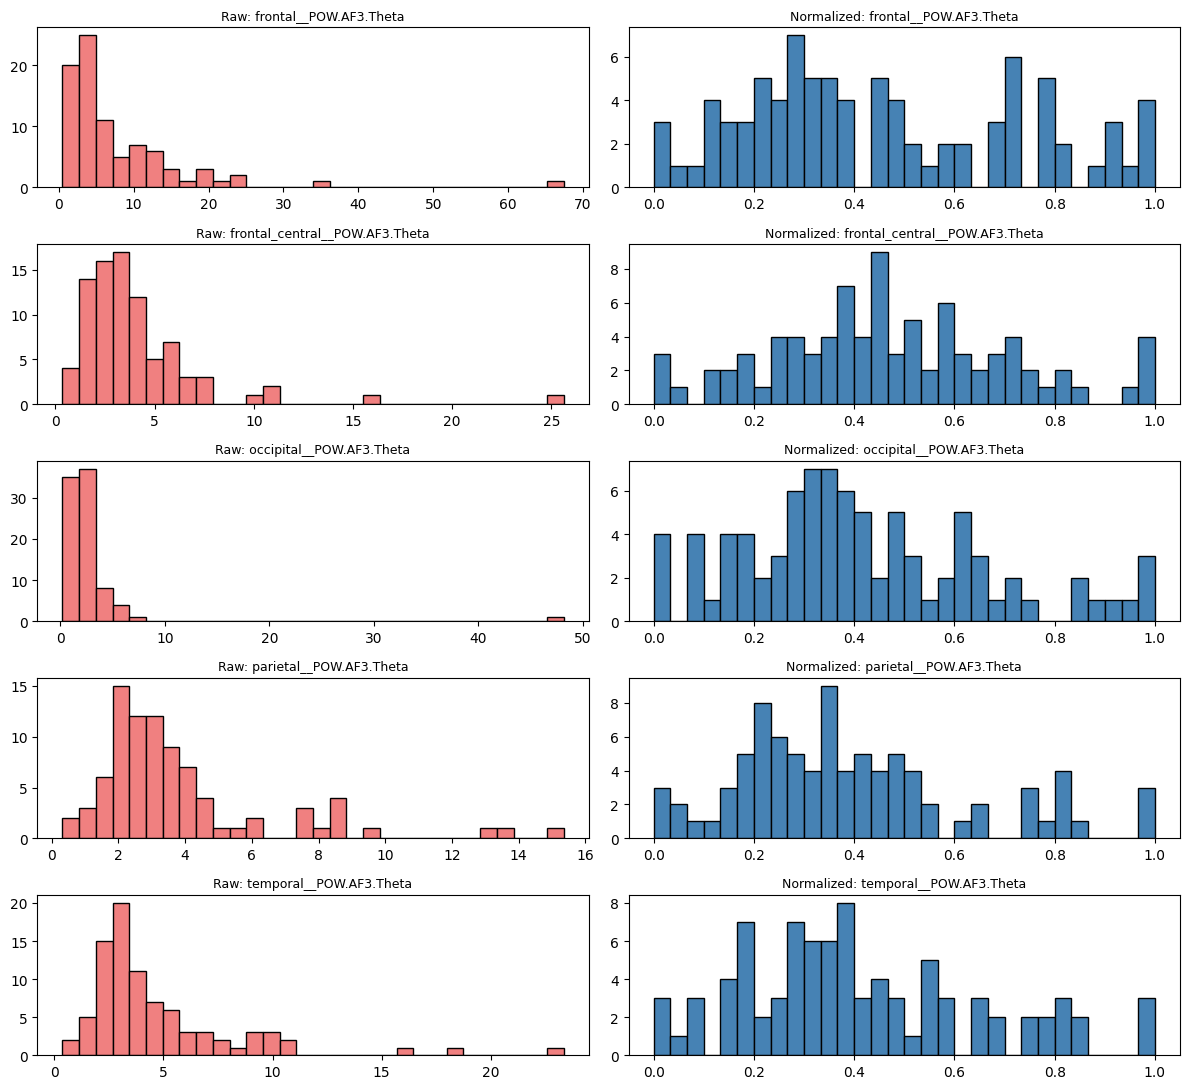

In [13]:
import matplotlib.pyplot as plt

categories_present = sorted(category_counts.keys())
sample_features = []
for cat in categories_present:
    matching = [c for c in feature_matrix.columns if c.startswith(f"{cat}__")]
    if matching:
        sample_features.append(matching[0])

fig, axes = plt.subplots(len(sample_features), 2, figsize=(12, 2.2 * len(sample_features)))
if len(sample_features) == 1:
    axes = axes.reshape(1, -1)
for i, feat in enumerate(sample_features):
    axes[i, 0].hist(feature_matrix_raw[feat].values, bins=30, color="lightcoral", edgecolor="black")
    axes[i, 0].set_title(f"Raw: {feat}", fontsize=9)
    axes[i, 1].hist(feature_matrix[feat].values, bins=30, color="steelblue", edgecolor="black")
    axes[i, 1].set_title(f"Normalized: {feat}", fontsize=9)
plt.tight_layout()
plt.show()

## Save outputs

In [14]:
feature_matrix.to_csv(OUTPUT_DIR / "feature_matrix.csv")
feature_matrix_raw.to_csv(OUTPUT_DIR / "feature_matrix_raw.csv")
metadata.to_csv(OUTPUT_DIR / "metadata.csv", index=False)

with open(OUTPUT_DIR / "build_report.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

log(f"\nSaved to {OUTPUT_DIR}:")
log(f"  feature_matrix.csv      ({feature_matrix.shape})")
log(f"  feature_matrix_raw.csv  ({feature_matrix_raw.shape})")
log(f"  metadata.csv            ({metadata.shape})")
log(f"  build_report.txt")


Saved to C:\Users\lukab\Desktop\Algebra EEG\Project NMF\outputs:
  feature_matrix.csv      ((86, 350))
  feature_matrix_raw.csv  ((86, 350))
  metadata.csv            ((86, 18))
  build_report.txt
